We create this code for the evaluation of rag applicatiosn using RAGAS(Retrieval Augmented Generation Assessment) open source framework..

In [ ]:
# ============================================================================
# ENVIRONMENT SETUP NOTES (for RAGAS evaluation)
# ----------------------------------------------------------------------------
# Python 3.13 (global) had no prebuilt numpy wheel for ragas==0.1.0's deps,
# and a later ragas version pulled in langchain-community which removed
# `langchain_community.chat_models.vertexai` -> ModuleNotFoundError.
# Fix: created an isolated Python 3.11 venv with pinned compatible versions.
#
# --- One-time setup (run in PowerShell, NOT in this notebook) ---
#
# 1. Install Python 3.11 (side-by-side with 3.13, doesn't affect global python)
#    Download from https://www.python.org/downloads/release/python-3119/
#
# 2. Verify both versions are visible:
#    py -0
#
# 3. Go to project folder:
#    cd "C:\Users\shara\OneDrive\Documents\Coding Stuff\Generative AI\LangChain"
#
# 4. Create the 3.11 virtual environment:
#    py -3.11 -m venv ragas_env
#
# 5. Allow script execution (one-time, if PowerShell blocks activation):
#    Set-ExecutionPolicy -Scope CurrentUser -ExecutionPolicy RemoteSigned
#
# 6. Activate the venv:
#    .\ragas_env\Scripts\Activate.ps1
#    -> prompt should now show (ragas_env)
#
# 7. Upgrade pip:
#    python -m pip install --upgrade pip
#
# 8. Install pinned, mutually-compatible package set:
#    pip install numpy==1.26.4 "langchain==0.2.16" "langchain-community==0.2.16" \
#        "langchain-core==0.2.43" "langchain-openai==0.1.23" langchain-chroma \
#        "ragas==0.1.16" datasets==2.16.1 pypdf python-dotenv ipykernel
#
# 9. Register this venv as a Jupyter kernel:
#    python -m ipykernel install --user --name=ragas_env --display-name "Python (ragas_env)"
#
# 10. In VS Code / Jupyter: select kernel "Python (ragas_env)" for this notebook.
#
# NOTE: Do NOT run any further `!pip install` cells inside this notebook --
# all dependencies are managed in ragas_env via the steps above. Re-running
# installs from within the notebook can pull in newer, incompatible versions
# (e.g. langchain-core 1.x) and break the ragas import again.
#
# Global Python 3.13 remains untouched -- this venv is fully isolated.
# ============================================================================

In [1]:
# install packages 
!pip install numpy -q
!pip install ragas==0.1.0 -q
!pip install langchain==0.3.2 -q
!pip install langchain-chroma -q
!pip install langchain-openai -q
!pip install datasets==2.16.1 -q
!pip install pypdf -q


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain-classic 1.0.8 requires langchain-core<2.0.0,>=1.4.4, but you have langchain-core 0.3.63 which is incompatible.
langchain-classic 1.0.8 requires langchain-text-splitters<2.0.0,>=1.1.2, but you have langchain-text-splitters 0.3.8 which is incompatible.
langchain-community 0.4.2 requires langchain-core<2.0.0,>=1.4.0, but you have langchain-core 0.3.63 which is incompatible.
langchain-openai 1.3.0 requires langchain-core<2.0.0,>=1.4.3, but you have langchain-core 0.3.63 which is incompatible.
langgraph 1.2.5 requires langchain-core<2,>=1.4.7, but you have langchain-core 0.3.63 which is incompatible.
langgraph-prebuilt 1.1.0 requires langchain-core>=1.3.1, but you have langchain-core 0.3.63 which is incompatible.
langgraph-sdk 0.4.2 requires langchain-core<2,>=1.4.0, but you have langchain-core 0.3.63 which i

In [3]:
#call the API key as an environment variable
#to manage API key as a local enviornment variable we need OS library, and to load the env variables from .env file we need to install python-dotenv package
%pip install python-dotenv

import os

#load openai key from .env file, first import the library to load env variables
from dotenv import load_dotenv
from pathlib import Path

env_path=Path.cwd() /'.env'#give the .env file path
print("Path to .env file:", env_path)
print("File exists:", env_path.exists())
# Load environment variables from .env file
load_dotenv(env_path,override=True)


#OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
api_key = os.getenv("OPENAI_API_KEY")
print("Loaded:", api_key is not None)
weather_key=os.getenv("OPEN_WEATHER_API_KEY")
print("Loaded:", weather_key is not None)

Note: you may need to restart the kernel to use updated packages.
Path to .env file: c:\Users\shara\OneDrive\Documents\Coding Stuff\Generative AI\LangChain\.env
File exists: True
Loaded: True
Loaded: True


In [4]:
#initialize the chatOPENAI model
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.9, openai_api_key=api_key)

In [5]:
#intialize a embedding model
from langchain_openai import OpenAIEmbeddings 
embedding=OpenAIEmbeddings(model='text-embedding-3-small')

In [6]:
#Load pdf loader
from langchain_community.document_loaders import PyPDFLoader

#initialize the pdf document loader
loader=PyPDFLoader("/Users/shara/OneDrive/Documents/Coding Stuff/Generative AI/LangChain/Documents/global_warming.pdf")
pdf_data=loader.load()

print(pdf_data)

[Document(metadata={'source': '/Users/shara/OneDrive/Documents/Coding Stuff/Generative AI/LangChain/Documents/global_warming.pdf', 'page': 0}, page_content="Global Warming: An Overview\nWhat is Global Warming?\nGlobal warming refers to the long-term rise in Earth's average surface temperature, driven\nprimarily by the accumulation of greenhouse gases in the atmosphere. Since the\npre-industrial era around 1850, global average temperatures have increased by approximately\n1.1 degrees Celsius. The Intergovernmental Panel on Climate Change (IPCC) has confirmed\nthat this warming trend is unequivocally linked to human industrial activity, not natural climate\nvariability.\nGreenhouse Gases\nThe primary greenhouse gases responsible for warming are carbon dioxide (CO2), methane\n(CH4), nitrous oxide (N2O), and fluorinated gases. Carbon dioxide is the most significant,\naccounting for about 76% of total greenhouse gas emissions. Atmospheric CO2 has risen\nfrom around 280 ppm before industrial

In [7]:
len(pdf_data)

3

In [8]:
#split the loaded pdf data into chunks using a splitter
from langchain_text_splitters import RecursiveCharacterTextSplitter

#intialize the text splitter with a chunck size of 300 and 50 overlap.
#here we use a chachter-level function to count the length of chunks(not the tiktoekn method at this moment)
text_splitter=RecursiveCharacterTextSplitter(chunk_size=300,chunk_overlap=40,length_function=len)#which means we create chunks with chrhactersize of 50.

#splits
splits=text_splitter.split_documents(pdf_data)

In [9]:
len(splits)

22

In [10]:
#Create vector store 
from langchain_chroma import Chroma

#create a vector store from created docuemtn chunks
vectorstore=Chroma.from_documents(documents=splits,embedding=embedding)

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


In [15]:
#create the retirever
retriever=vectorstore.as_retriever(search_kwargs={"k":2})# retireve best 2 chunks

In [12]:
#define prompt template
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough

#define a message tempalte for the chatbot
message="""Answer this question using provided context only. {question} Context: {context}"""

#Create a chat prompt template from the message
prompt=ChatPromptTemplate.from_messages([("human",message)])


In [13]:
from langchain_core.output_parsers import StrOutputParser

chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

In [16]:
#invoke the chain with a example question
response=chain.invoke("what is global warming")
print(response)

Global warming refers to the long-term rise in Earth's average surface temperature, primarily driven by the accumulation of greenhouse gases in the atmosphere.


Evalaute the prepared RAG application

In [17]:
import pandas as pd
test_data = pd.read_csv(r"C:\Users\shara\OneDrive\Documents\Coding Stuff\Generative AI\LangChain\Documents\rag_evaluation_qa.csv")
test_data

,Question,Answer
0,By how much has the global average temperature...,Approximately 1.1 degrees Celsius since around...
1,What is the current atmospheric concentration ...,"Over 421 ppm, the highest in at least 3 millio..."
2,What was the pre-industrial level of atmospher...,Approximately 280 ppm.
3,What percentage of total greenhouse gas emissi...,About 76% of total global greenhouse gas emiss...
4,How many times more potent is methane than CO2...,Approximately 28 times more potent.
5,What is the largest source of global greenhous...,"Burning fossil fuels for energy and transport,..."
6,What percentage of emissions comes from defore...,About 10 to 12% of annual CO2 emissions.
7,How much has global sea level risen since 1900?,"Approximately 20 cm, currently rising at 3.6 m..."
8,By what percentage has Arctic sea ice Septembe...,Around 13% per decade.
9,How much more likely are extreme heat events c...,Five times more likely.


In [18]:
questions=test_data["Question"].to_list()
ground_truth=test_data["Answer"].to_list()

In [19]:
#prepare a dictionary for our test data details. we can alrdy fill it with ground truthe since we know it for each question.
data={"question":[],"answer":[],"contexts":[],"ground_truth":ground_truth}

In [20]:
data

{'question': [],
 'answer': [],
 'contexts': [],
 'ground_truth': ['Approximately 1.1 degrees Celsius since around 1850.',
  'Over 421 ppm, the highest in at least 3 million years.',
  'Approximately 280 ppm.',
  'About 76% of total global greenhouse gas emissions.',
  'Approximately 28 times more potent.',
  'Burning fossil fuels for energy and transport, contributing approximately 75% of global emissions.',
  'About 10 to 12% of annual CO2 emissions.',
  'Approximately 20 cm, currently rising at 3.6 mm per year.',
  'Around 13% per decade.',
  'Five times more likely.',
  'Thresholds beyond which large-scale changes become self-sustaining and irreversible.',
  'Approximately 1.5 trillion tonnes of frozen organic carbon.',
  'By around 2050, according to the IPCC.',
  'By 295 GW in 2022 alone.',
  'Around 10,000 tonnes of CO2 per year globally as of 2023.',
  'To limit warming to well below 2 degrees Celsius, with efforts toward 1.5 degrees.',
  'Approximately 2.5 to 2.9 degrees Celsi

In [21]:
#fill the dictionary with the qustion, and apppropriate answer from the RAG chain we created.  and also we add the context with the retrival chunks form the vector database for each question.
for query in questions:
    data["question"].append(query)
    data["answer"].append(chain.invoke(query))
    data["contexts"].append([doc.page_content for doc in retriever.invoke(query)])

In [22]:
data

{'question': ['By how much has the global average temperature risen since the pre-industrial era?',
  'What is the current atmospheric concentration of CO2 as of 2023?',
  'What was the pre-industrial level of atmospheric CO2?',
  'What percentage of total greenhouse gas emissions does CO2 account for?',
  'How many times more potent is methane than CO2 over a 100-year period?',
  'What is the largest source of global greenhouse gas emissions?',
  'What percentage of emissions comes from deforestation and land use change?',
  'How much has global sea level risen since 1900?',
  'By what percentage has Arctic sea ice September extent declined?',
  'How much more likely are extreme heat events compared to the pre-industrial era?',
  'What are climate tipping points?',
  'How much CO2 could be released from thawing permafrost regions?',
  'By when must global CO2 emissions reach net-zero to limit warming to 1.5 degrees Celsius?',
  'How much did global renewable electricity capacity grow 

In [23]:
#make dictionar in the dataset format. Because a dataset object is easy to
from datasets import Dataset
dataset=Dataset.from_dict(data)

c:\Users\shara\OneDrive\Documents\Coding Stuff\Generative AI\LangChain\ragas_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
#check the dataset
dataset[5]

{'question': 'What is the largest source of global greenhouse gas emissions?',
 'answer': 'The largest source of global greenhouse gas emissions is burning fossil fuels for energy and transport, contributing approximately 75% of emissions.',
 'contexts': ['CO2 over a 100-year period.\nMain Causes\nBurning fossil fuels for energy and transport is the largest source, contributing approximately\n75% of global greenhouse gas emissions. Deforestation adds another 10 to 12%, as trees',
  'that once absorbed CO2 are cleared, mainly for agriculture. The agriculture sector itself,\nthrough livestock farming and fertiliser use, contributes a further 10 to 12% of emissions.\nIndustrial processes such as cement and steel production account for roughly 5% of global\nemissions.'],
 'ground_truth': 'Burning fossil fuels for energy and transport, contributing approximately 75% of global emissions.'}

In [26]:
#Now we use the ragas to evlauaet the dataset
from ragas.metrics import context_precision,context_recall,answer_relevancy,faithfulness
from ragas import evaluate

result=evaluate(dataset=dataset,metrics=[context_precision,context_recall,answer_relevancy,faithfulness])

Evaluating: 100%|██████████| 80/80 [00:31<00:00,  2.55it/s]


In [27]:
result

{'context_precision': 0.8750, 'context_recall': 0.9000, 'answer_relevancy': 0.9818, 'faithfulness': 0.9125}

In [28]:
results=result.to_pandas()

In [30]:
results

,question,answer,contexts,ground_truth,context_precision,context_recall,answer_relevancy,faithfulness
0,By how much has the global average temperature...,The global average temperature has risen by ap...,"[pre-industrial era around 1850, global averag...",Approximately 1.1 degrees Celsius since around...,1.0,1.0,0.999998,1.00
1,What is the current atmospheric concentration ...,The current atmospheric concentration of CO2 a...,[from around 280 ppm before industrialisation ...,"Over 421 ppm, the highest in at least 3 millio...",1.0,1.0,1.000000,1.00
2,What was the pre-industrial level of atmospher...,The pre-industrial level of atmospheric CO2 wa...,[from around 280 ppm before industrialisation ...,Approximately 280 ppm.,1.0,1.0,0.999998,1.00
3,What percentage of total greenhouse gas emissi...,CO2 accounts for approximately 75% of total gr...,"[that once absorbed CO2 are cleared, mainly fo...",About 76% of total global greenhouse gas emiss...,0.0,0.0,1.000000,0.00
4,How many times more potent is methane than CO2...,Methane is roughly 28 times more potent than C...,[from around 280 ppm before industrialisation ...,Approximately 28 times more potent.,1.0,1.0,0.990937,1.00
5,What is the largest source of global greenhous...,The largest source of global greenhouse gas em...,[CO2 over a 100-year period.\nMain Causes\nBur...,"Burning fossil fuels for energy and transport,...",1.0,1.0,0.999999,1.00
6,What percentage of emissions comes from defore...,10 to 12% of emissions comes from deforestatio...,[CO2 over a 100-year period.\nMain Causes\nBur...,About 10 to 12% of annual CO2 emissions.,1.0,1.0,0.999998,0.50
7,How much has global sea level risen since 1900?,Global sea levels have risen by about 20 cm si...,[emissions.\nObserved Impacts\nThe consequence...,"Approximately 20 cm, currently rising at 3.6 m...",1.0,1.0,0.996742,1.00
8,By what percentage has Arctic sea ice Septembe...,Arctic sea ice September extent has declined b...,[emissions.\nObserved Impacts\nThe consequence...,Around 13% per decade.,1.0,1.0,0.936048,1.00
9,How much more likely are extreme heat events c...,Extreme heat events are now significantly more...,"[pre-industrial era around 1850, global averag...",Five times more likely.,0.0,0.0,0.950190,0.75


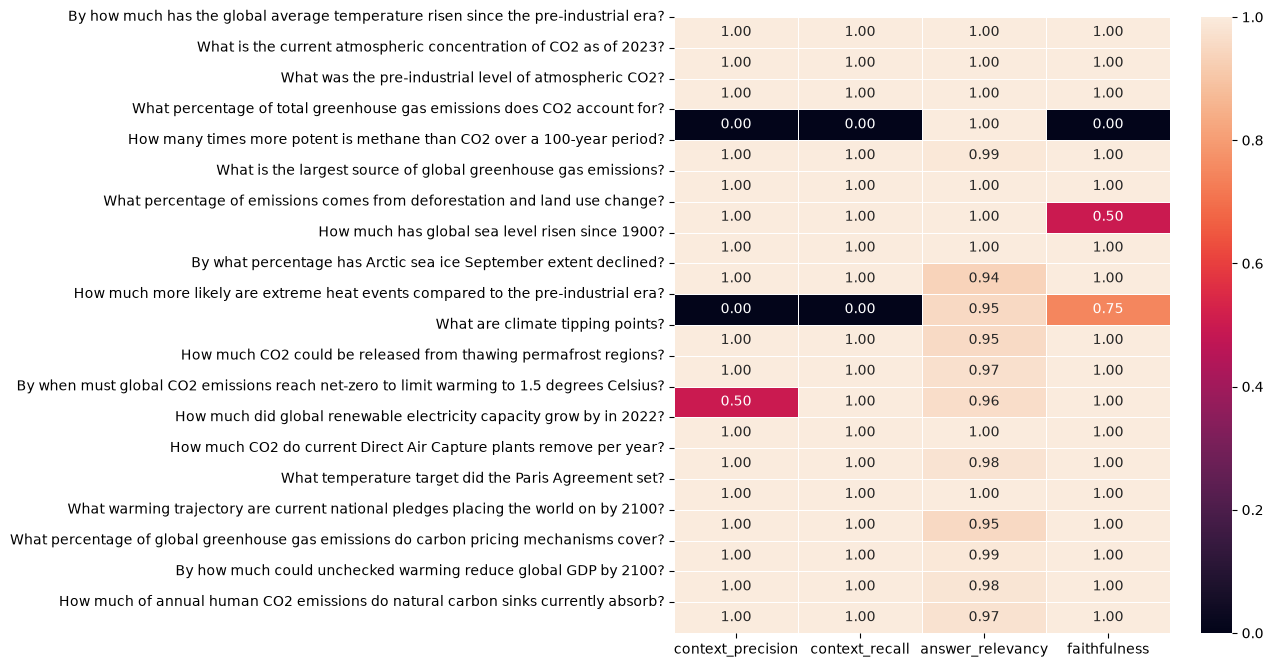

In [33]:
#3 now we vsualize the results with the seaborn
!pip install seaborn -q
import seaborn as sns
import matplotlib.pyplot as plt

heatmap_data=results[['context_precision','context_recall','answer_relevancy','faithfulness']]
plt.figure(figsize=(8,8))
sns.heatmap(heatmap_data,annot=True,fmt=".2f",linewidths=0.5)
plt.yticks(ticks=range(len(results['question'])),labels=results['question'],rotation=0)
plt.show()
